C:\Users\jrand\AppData\Local\Temp\ipykernel_19232\3724628117.py:56: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


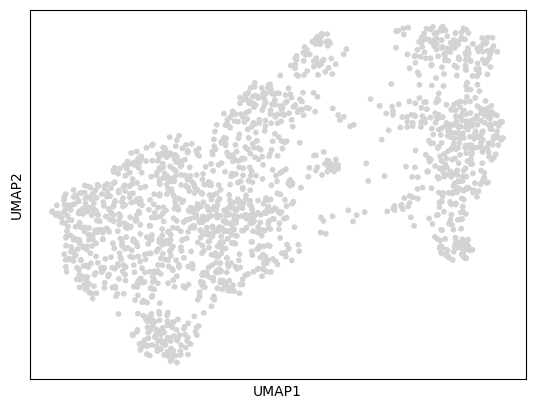

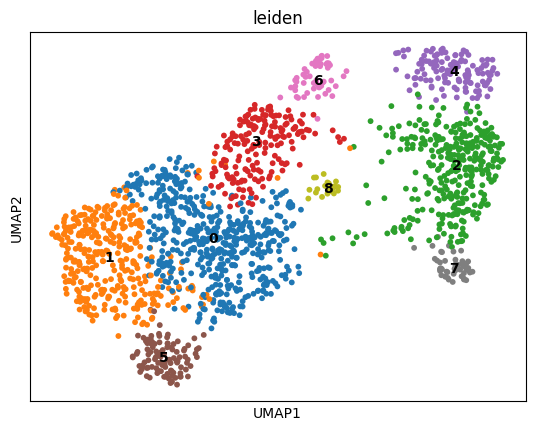

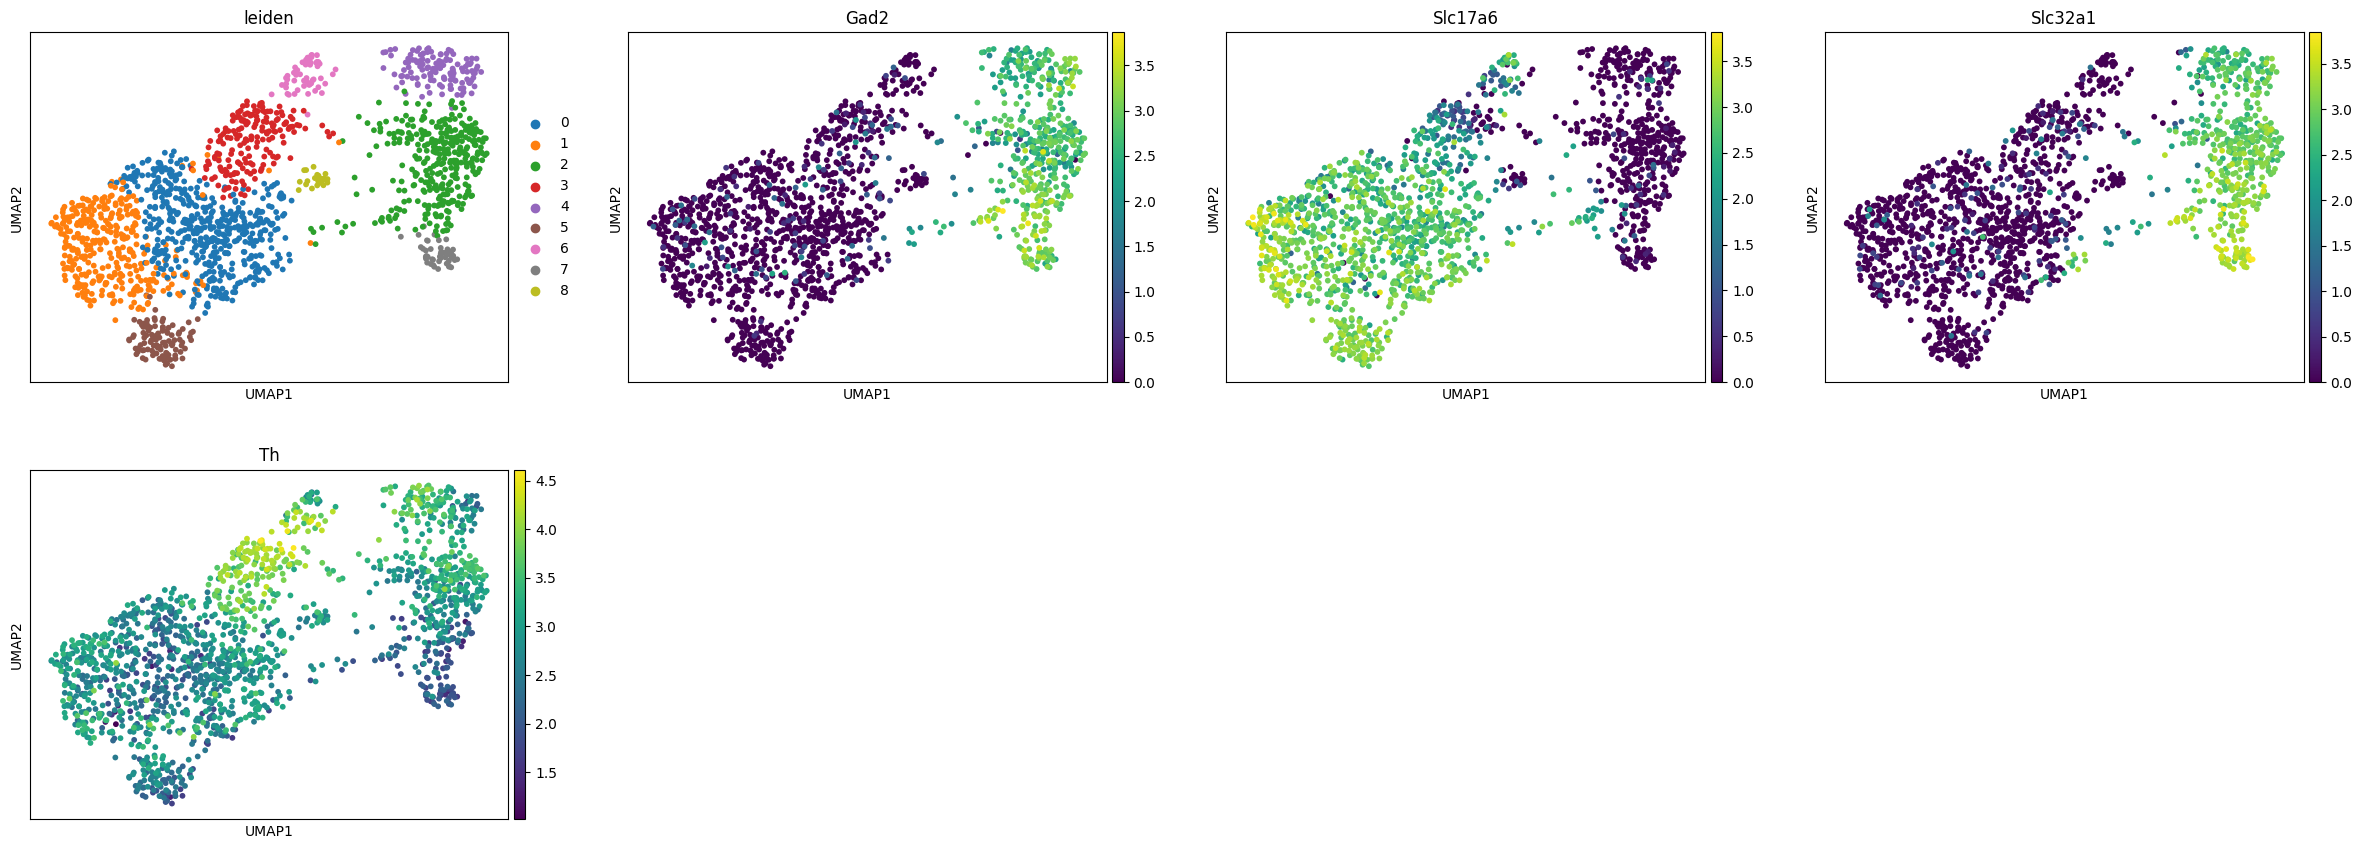

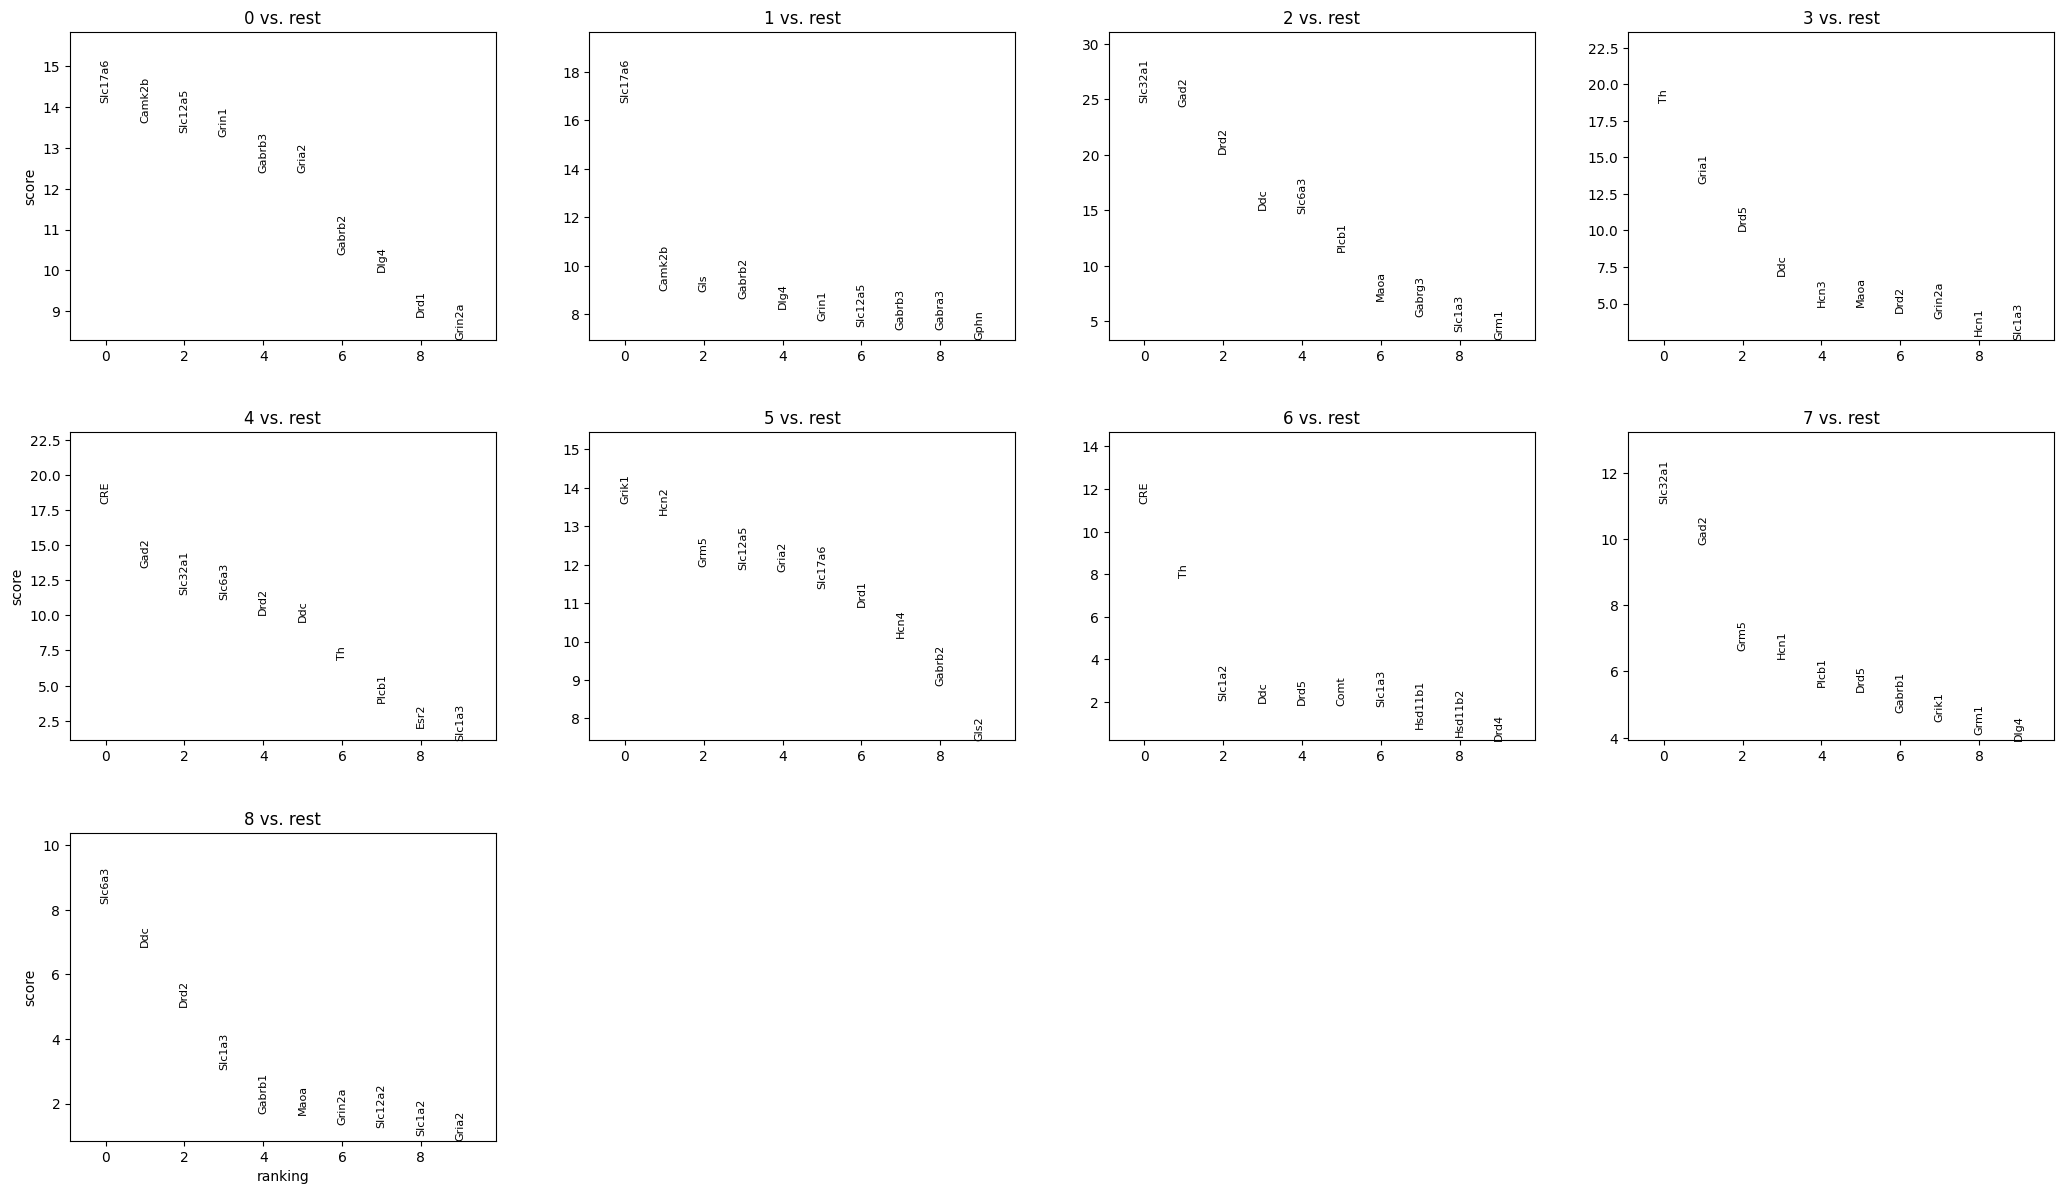

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Slc17a6,14.092786,2.008257,4.206330e-45,2.103165e-43
1,0,Camk2b,13.606603,0.543727,3.658589e-42,6.097648e-41
2,0,Slc12a5,13.370044,0.575601,9.048792e-41,1.131099e-39
3,0,Grin1,13.270612,0.625239,3.427722e-40,3.427722e-39
4,0,Gabrb3,12.398105,0.638560,2.675766e-35,1.785491e-34
5,0,Gria2,12.392858,0.592971,2.856786e-35,1.785491e-34
6,0,Gabrb2,10.375464,0.963367,3.206498e-25,1.457499e-24
7,0,Dlg4,9.967349,0.433406,2.118074e-23,8.825308e-23
8,0,Drd1,8.859836,1.307943,8.013241e-19,3.082016e-18
9,0,Grin2a,8.301207,0.857164,1.030592e-16,3.680685e-16


In [1]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc
import pandas as pd


# sc.settings.set_figure_params(dpi=50, facecolor="white")

# EXAMPLE_DATA = pooch.create(
#     path=pooch.os_cache("scverse_tutorials"),
#     base_url="doi:10.6084/m9.figshare.22716739.v1/",
# )
# EXAMPLE_DATA.load_registry_from_doi()

# samples = {
#     "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
#     "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
# }
# adatas = {}

# for sample_id, filename in samples.items():
#     path = EXAMPLE_DATA.fetch(filename)
#     sample_adata = sc.read_10x_h5(path)
#     sample_adata.var_names_make_unique()
#     adatas[sample_id] = sample_adata

# adata = ad.concat(adatas, label="sample")
# adata.obs_names_make_unique()
# print("adata")
# print(adata.obs)
# print(adata.obs["sample"].value_counts())
# adata

# adata = sc.read_csv("./output/combined_th_filtered_transcript_counts.csv", first_column_names=True)

df = pd.read_csv("./output/combined_th_filtered_transcript_counts.csv", index_col=0)
adata = sc.AnnData(df)


# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# Normalize
# sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# PCA + neighbors + cluster
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# UMAP
sc.tl.umap(adata)

# plot the UMAP embedding
sc.pl.umap(adata)

# Build graph used for clustering + UMAP
sc.pp.neighbors(adata)

# Cluster (Leiden is common)
sc.tl.leiden(adata, resolution=0.5)  # try 0.2–2.0 depending on granularity

# UMAP
sc.tl.umap(adata)

# Plot UMAP colored by clusters
sc.pl.umap(adata, color="leiden", legend_loc="on data")

sc.pl.umap(adata, color=["leiden", "Gad2", "Slc17a6", "Slc32a1", "Th"])


sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",   # common default
    use_raw=False        # set True only if you stored adata.raw
)

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)
sc.get.rank_genes_groups_df(adata, group=None).head(20)
